# PCA, t-SNE, and UMAP Exploration
This notebook demonstrates dimensionality reduction and embedding techniques using the Titanic dataset. We cover PCA for feature reduction, and t-SNE plus UMAP for visualization.

## 1. Goals
- Load a dataset and prepare numeric features.
- Apply PCA and inspect explained variance.
- Visualize high-dimensional data using t-SNE.
- Visualize the same data using UMAP if available.
- Compare the embeddings in a single plot.

In [1]:
# 2. Load libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split

# Optional UMAP import will be handled later

plt.style.use("seaborn-v0_8")

In [2]:
# 3. Load the Titanic dataset
path = os.path.join("..", "data", "titanic.csv")
if not os.path.exists(path):
    raise FileNotFoundError(f"Dataset not found at {path}. Place titanic.csv in the data folder.")

df = pd.read_csv(path)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 4. Data preparation
We will use a small set of numeric and categorical features, impute missing values, and scale the numeric variables.

In [3]:
feature_columns = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
X = df[feature_columns]
y = df["survived"]

numeric_features = ["age", "sibsp", "parch", "fare"]
categorical_features = ["pclass", "sex", "embarked"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

X_processed = preprocessor.fit_transform(X)
print("Processed feature matrix shape:", X_processed.shape)

Processed feature matrix shape: (891, 12)


## 5. PCA for dimensionality reduction
PCA finds orthogonal directions that explain the most variance. We will first inspect the explained variance ratio.

In [4]:
pca = PCA(n_components=5, random_state=42)
X_pca = pca.fit_transform(X_processed)

print("PCA component shape:", X_pca.shape)
print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 4))
print("Cumulative explained variance:", np.round(np.cumsum(pca.explained_variance_ratio_), 4))

PCA component shape: (891, 5)
Explained variance ratio: [0.3037 0.234  0.1321 0.1091 0.074 ]
Cumulative explained variance: [0.3037 0.5377 0.6698 0.7789 0.853 ]


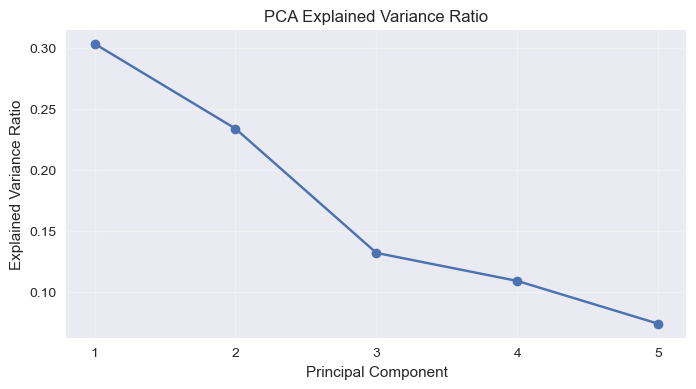

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, marker="o")
plt.title("PCA Explained Variance Ratio")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.xticks(np.arange(1, len(pca.explained_variance_ratio_) + 1))
plt.grid(True, alpha=0.3)
plt.show()

## 6. t-SNE visualization
t-SNE is a non-linear embedding technique optimized for visualizing local structure. It is useful for exploring clusters but not for preserving global distances.

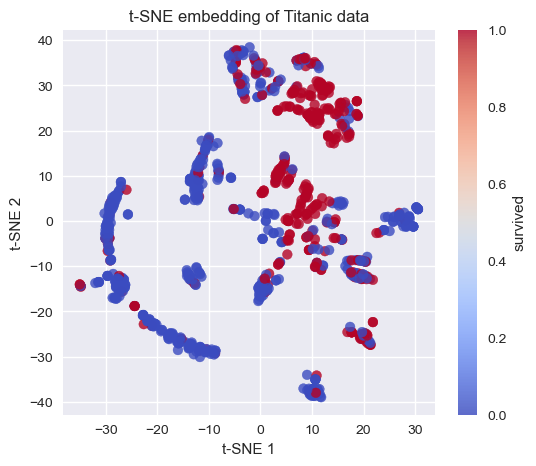

In [6]:
X_tsne = TSNE(
    n_components=2,
    random_state=42,
    learning_rate="auto",
    init="pca",
    perplexity=30,
).fit_transform(X_processed)

plt.figure(figsize=(6, 5))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="coolwarm", alpha=0.8)
plt.title("t-SNE embedding of Titanic data")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.colorbar(label="survived")
plt.show()

## 7. UMAP visualization
UMAP is another nonlinear embedding method that often preserves both local and global structure better than t-SNE. It is optional depending on whether `umap-learn` is installed.

/opt/anaconda3/envs/ML_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/envs/ML_env/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/anaconda3/envs/ML_env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


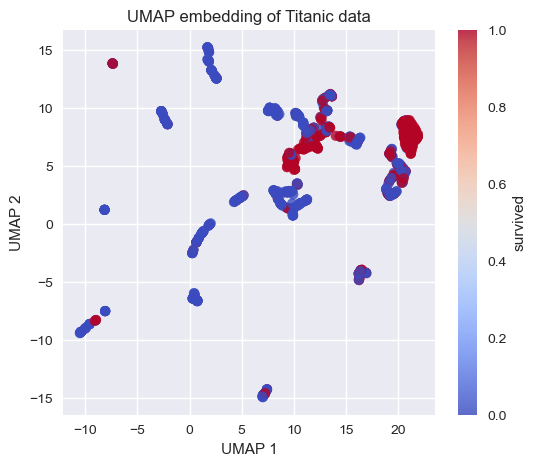

In [8]:
import umap
import importlib
umap_spec = importlib.util.find_spec("umap")
if umap_spec is not None:

    reducer = umap.UMAP(n_components=2, random_state=42)
    X_umap = reducer.fit_transform(X_processed)

    plt.figure(figsize=(6, 5))
    plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap="coolwarm", alpha=0.8)
    plt.title("UMAP embedding of Titanic data")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.colorbar(label="survived")
    plt.show()
else:
    print("UMAP is not installed. Run `pip install umap-learn` to enable UMAP visualizations.")

## 8. Embedding comparison
Comparing PCA, t-SNE, and UMAP can help reveal how each method represents the same underlying structure.
PCA is linear and preserves global variance. t-SNE and UMAP are nonlinear and often show clusters more clearly.

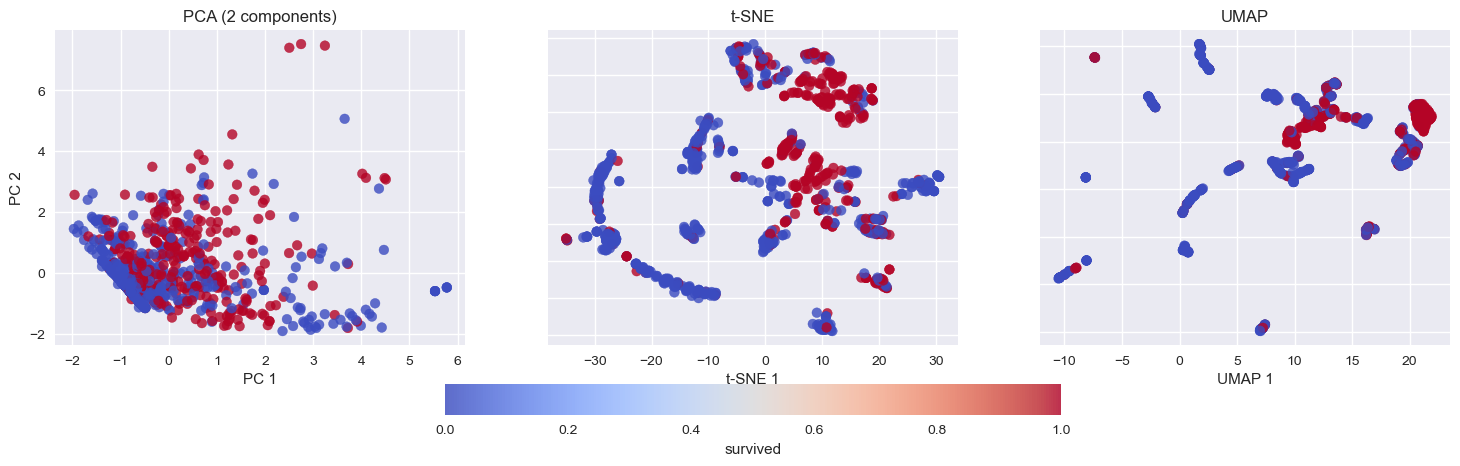

In [9]:
if umap_spec is not None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="coolwarm", alpha=0.8)
    axes[0].set_title("PCA (2 components)")
    axes[0].set_xlabel("PC 1")
    axes[0].set_ylabel("PC 2")

    axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="coolwarm", alpha=0.8)
    axes[1].set_title("t-SNE")
    axes[1].set_xlabel("t-SNE 1")
    axes[1].set_ylabel("t-SNE 2")

    axes[2].scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap="coolwarm", alpha=0.8)
    axes[2].set_title("UMAP")
    axes[2].set_xlabel("UMAP 1")
    axes[2].set_ylabel("UMAP 2")

    for ax in axes:
        ax.label_outer()

    fig.colorbar(axes[0].collections[0], ax=axes, orientation="horizontal", fraction=0.08, pad=0.1, label="survived")
    plt.show()
else:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="coolwarm", alpha=0.8)
    axes[0].set_title("PCA (2 components)")
    axes[0].set_xlabel("PC 1")
    axes[0].set_ylabel("PC 2")

    axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="coolwarm", alpha=0.8)
    axes[1].set_title("t-SNE")
    axes[1].set_xlabel("t-SNE 1")
    axes[1].set_ylabel("t-SNE 2")

    for ax in axes:
        ax.label_outer()

    fig.colorbar(axes[0].collections[0], ax=axes, orientation="horizontal", fraction=0.08, pad=0.1, label="survived")
    plt.show()

## 9. Summary
- PCA is a linear method that preserves variance and is useful for dimensionality reduction and feature inspection.
- t-SNE is a nonlinear embedding that often reveals clusters, especially in complex datasets.
- UMAP is another nonlinear method with good local-global structure preservation and faster runtime for larger datasets.
- Use PCA for preprocessing and variance analysis, and use t-SNE / UMAP for visualization.